In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
# dt = ds.Coco("/home/wanderer2414/coco2017/")
from torch.utils.data import DataLoader
from dataset2 import YOLODataset, test
import config
from torch import tensor, arange, float as tfloat, stack
import matplotlib.pyplot as plt
import matplotlib.patches as pat
dt = ds.Coco("/home/wanderer2414/PASCAL_VOC")
# coco = YOLODataset("../COCO/test.csv", "../COCO/")
# loader = DataLoader

/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()
/home/wanderer2414/MyRCNN/config.py:65: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/home/wanderer2414/.conda/envs/mtr/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/wanderer2414/MyRCNN/config.py:75: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRot

In [2]:
# import MyRCNN
# import torch
# dev = "cpu"
# model = MyRCNN.Model(device=torch.device(dev))
# model.model.load_state_dict(torch.load("bbx.pth", map_location=dev))
def count_parameters(model):
        return sum(p.numel() for p in model.parameters())

# print(count_parameters(model.model.color))

In [3]:
import MyRCNN
import torch
device = "cuda"
model = MyRCNN.Model(dt,device=torch.device(device))
print(count_parameters(model.model))
# for module in model.model.color.prepare.modules():
#     print(module)
model.train()

893
Load model!
Load model!


In [ ]:
model.Evaluate()

torch.Size([1, 1, 500, 335])
[00:22:12] AP: 0.033333297818899155                                                                  1        /     4951torch.Size([1, 1, 375, 500])
[00:15:12] AP: 0.03749995678663254                                                                   2        /     4951torch.Size([1, 1, 406, 500])
[00:13:17] AP: 0.027976160869002342                                                                  3        /     4951torch.Size([1, 1, 375, 500])
[00:12:04] AP: 0.02807931788265705                                                                   4        /     4951torch.Size([1, 1, 375, 500])
[00:11:11] AP: 0.02246345393359661                                                                   5        /     4951torch.Size([1, 1, 480, 354])
[00:10:35] AP: 0.021497318521142006                                                                  6        /     4951torch.Size([1, 1, 324, 500])
[00:10:05] AP: 0.01842627301812172                                           

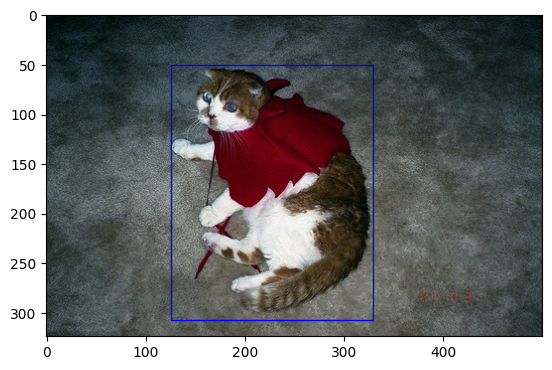

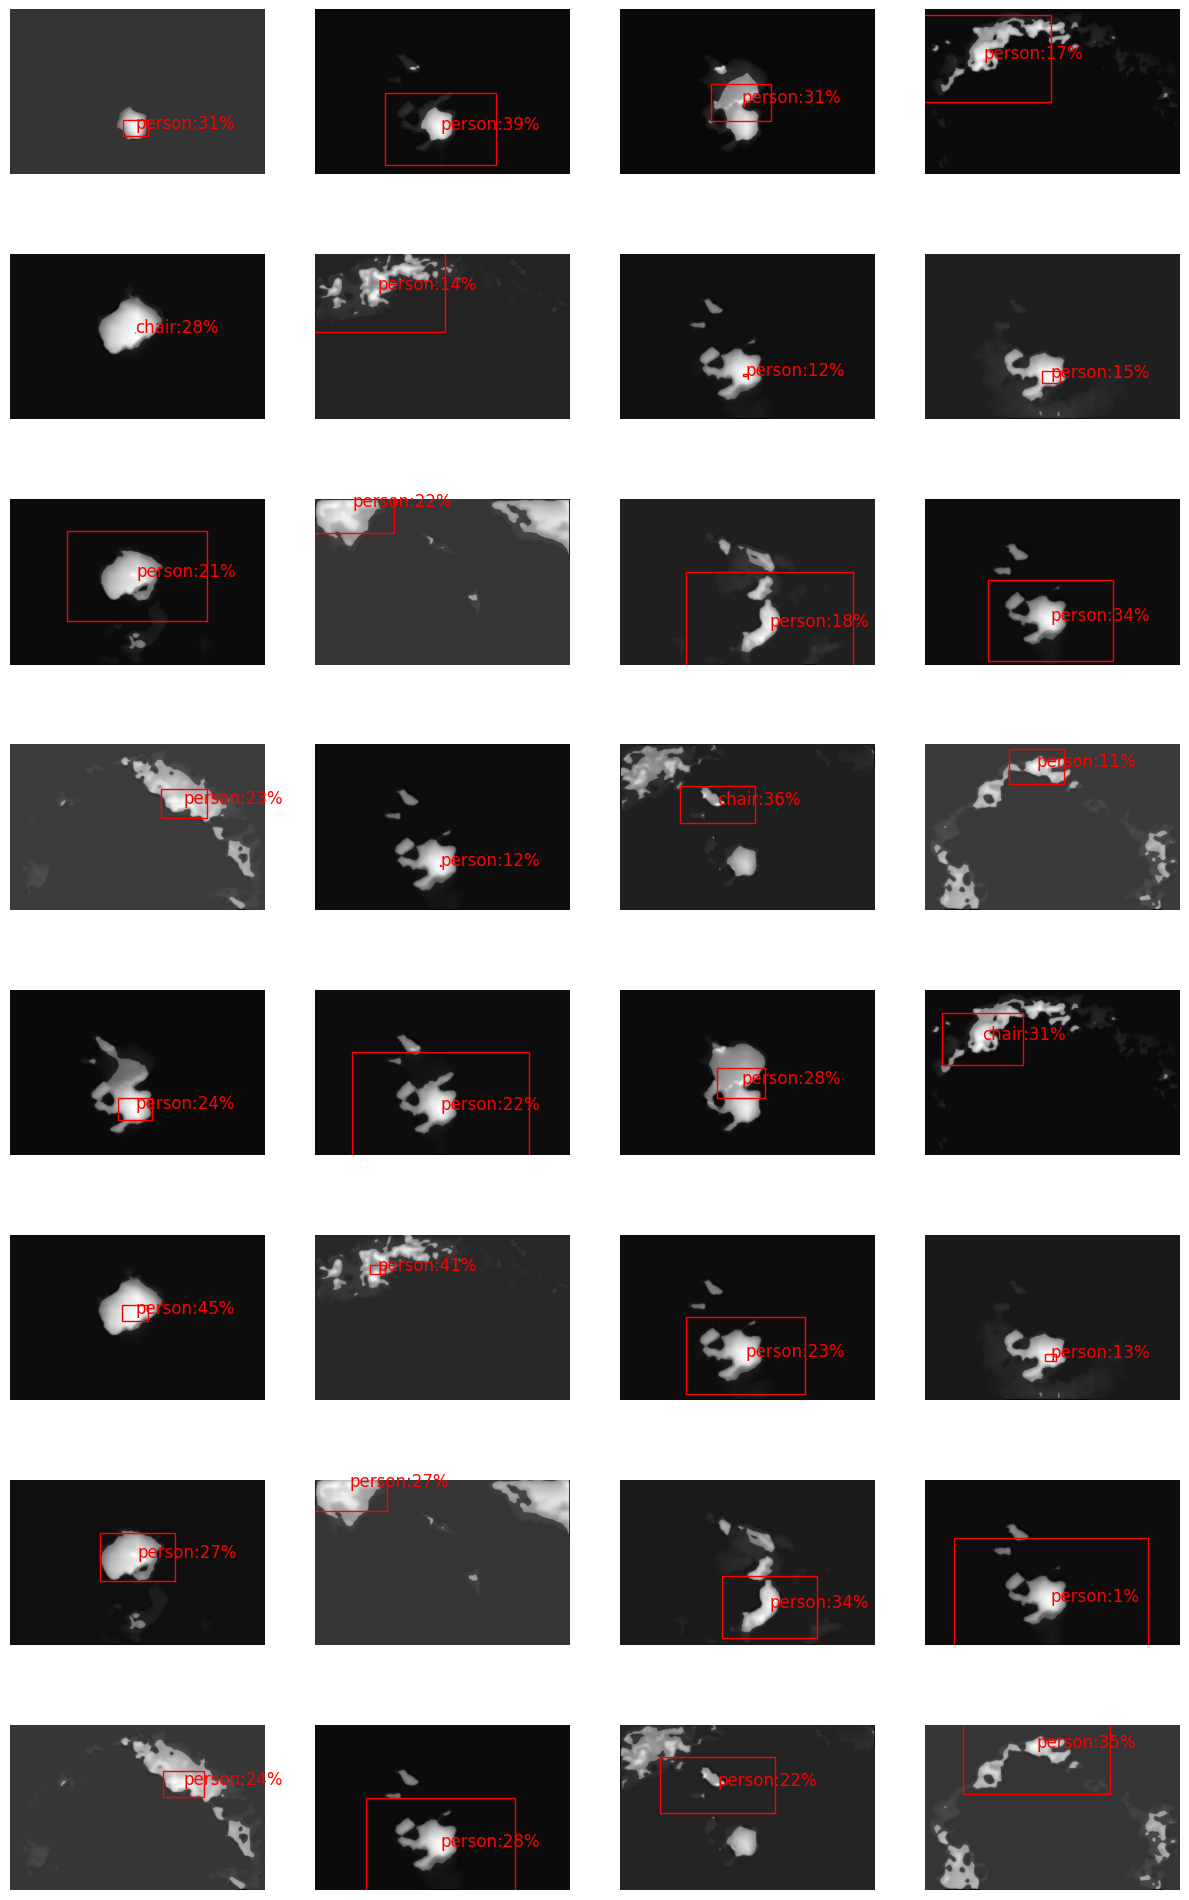

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from torch import sigmoid, softmax, zeros, bool as tbool
from dataset import TensorToImg, ImgToTensor
i = 6
x = dt.getTestTensor(i).to(device=torch.device(device))
label = dt.getTestLabel(i)

boundary, mask, color, score, bbx = model.model(x)
x1, y1, x2, y2, cls = label[0]
rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='blue')
plt.subplot().add_patch(rect)
plt.imshow(TensorToImg(x.detach().cpu()))

boxes = model.inference(x)

N = color.shape[1]
# boxes = boxes.view(N, -1, 6).permute(0, 2, 1)
# tv = sigmoid(boxes[:, :, 19].flatten())
# print((tv*100).long())
boxes = boxes.view(N, -1, 6)
cls = softmax(boxes[:, :, 1:2].view(N, -1), dim=-1)
indices = cls.max(dim=-1).indices.view(-1, 1)
indices = zeros(indices.shape[0], 20, dtype=tbool, device=indices.device).scatter(-1, indices, True).unsqueeze(-1).expand(-1, 20, 6)
boxes = boxes[indices].view(N, 6)

# boxes = softmax(boxes, dim=-1)
# boxes = softmax(boxes, dim=1)
# box_show = boxes.permute(0, 2, 1).reshape(-1, 20)
# print(box_show.shape)
# print((box_show[:, 19]*100).long())
# fig, axes = plt.subplots(N//4, 4, figsize=(12, 20))
# cls_range = arange(20).view(20, 1, 1).expand(20, N, 1)
# for i, ax in enumerate(axes.flat):
#     x = color[:, i:i+1, :, :]
#     x = x.repeat(1, 3, 1, 1)
#     x = x-x.min()
#     x = x/x.max()
#     cls, score, x1, y1, x2, y2 = boxes[i].detach().cpu().numpy()
#     rect = pat.Rectangle((x1, y1), x2-x1, y2-y1, facecolor='none', edgecolor='red')
#     ax.add_patch(rect)
#     ax.text((x1+x2)/2, (y1+y2)/2, f"{config.PASCAL_CLASSES[cls.astype(int)]}:{(score*100).astype(int)}%", fontsize=12, color='red')
#     ax.imshow(TensorToImg(x.detach().cpu()))
#     ax.axis('off')
plt.tight_layout()
plt.show()
